In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-18 12:12:25.404211


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams['figure.figsize'] = (3,3)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "figures"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

In [6]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

# Refined gene signature

Double⁺ neurons are classified within the CGRP-γ subtype but appear to be negative for Adra2a, a previously reported marker gene. Would it be feasible to compare Double⁺ neurons with other CGRP-γ neurons to derive a more refined gene signature?

In [7]:
adata.obs.seurat_labels.value_counts()

seurat_labels
CGRP-Gamma                    6186
Nonpeptidergic nociceptors    3513
CGRP-Eta                      1963
CGRP-Zeta                     1493
Abeta-RA-LTMR                 1463
Abeta-Field                   1452
C-LTMR                        1402
Adelta-LTMR                   1020
CGRP-Theta                     868
Proprioceptors                 864
TrpM8                          650
CGRP-Epsilion                  609
Sst                            554
CGRP-Alpha                     245
CGRP-Beta                      129
Name: count, dtype: int64

In [8]:
adata = adata[adata.obs['seurat_labels'] == 'CGRP-Gamma'].copy()

In [9]:
adata.obs.EGFP_dTomato_dual_hi.value_counts() # note removed one CGRP-eta

EGFP_dTomato_dual_hi
False    6168
True       18
Name: count, dtype: int64

In [10]:
adata.obs["EGFP_dTomato_dual_hi"] = adata.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")


In [11]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,False,Lcorl,5.214812,2.628756,1.840035e-07,0.000007
1,False,Kit,5.001419,1.793938,5.690982e-07,0.000019
2,False,6330403K07Rik,4.945708,1.053685,7.586747e-07,0.000023
3,False,Gria1,4.702180,2.306012,2.573985e-06,0.000061
4,False,Trpv1,4.672573,2.173988,2.974494e-06,0.000067
...,...,...,...,...,...,...
945,True,Trpv1,-4.672573,-2.173988,2.974494e-06,0.000067
946,True,Gria1,-4.702180,-2.306012,2.573985e-06,0.000061
947,True,6330403K07Rik,-4.945708,-1.053685,7.586747e-07,0.000023
948,True,Kit,-5.001419,-1.793938,5.690982e-07,0.000019


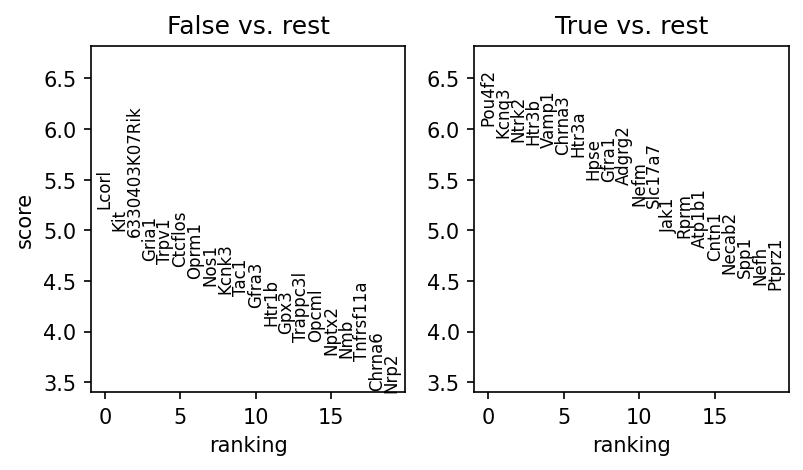

In [12]:
sc.pl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

In [13]:
top10 = (
    markers[markers["group"] == 'True']
    .sort_values("scores", ascending=False)
    .head(10)["names"]
    .tolist()
)

In [14]:
top10

['Pou4f2',
 'Kcnq3',
 'Ntrk2',
 'Htr3b',
 'Vamp1',
 'Chrna3',
 'Htr3a',
 'Hpse',
 'Gfra1',
 'Adgrg2']

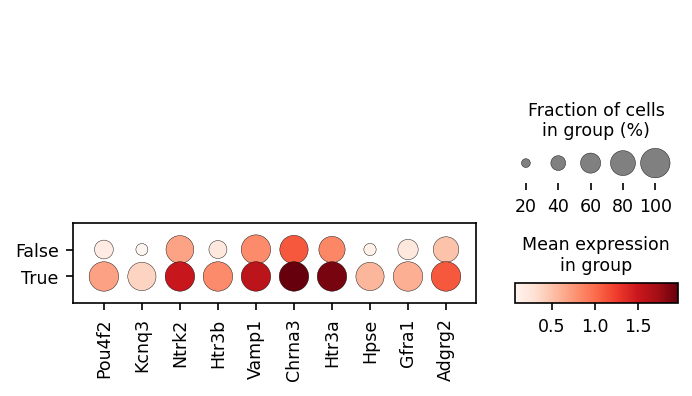

In [15]:
sc.pl.dotplot(adata, var_names = top10, groupby = 'EGFP_dTomato_dual_hi', cmap = 'Reds')

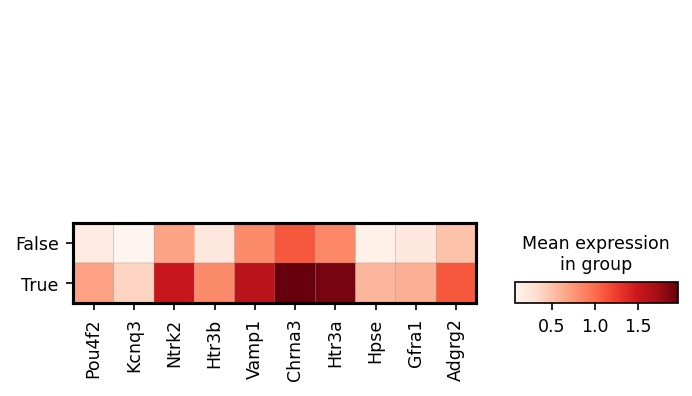

In [16]:
sc.pl.matrixplot(adata, var_names = top10, groupby = 'EGFP_dTomato_dual_hi', cmap = 'Reds')

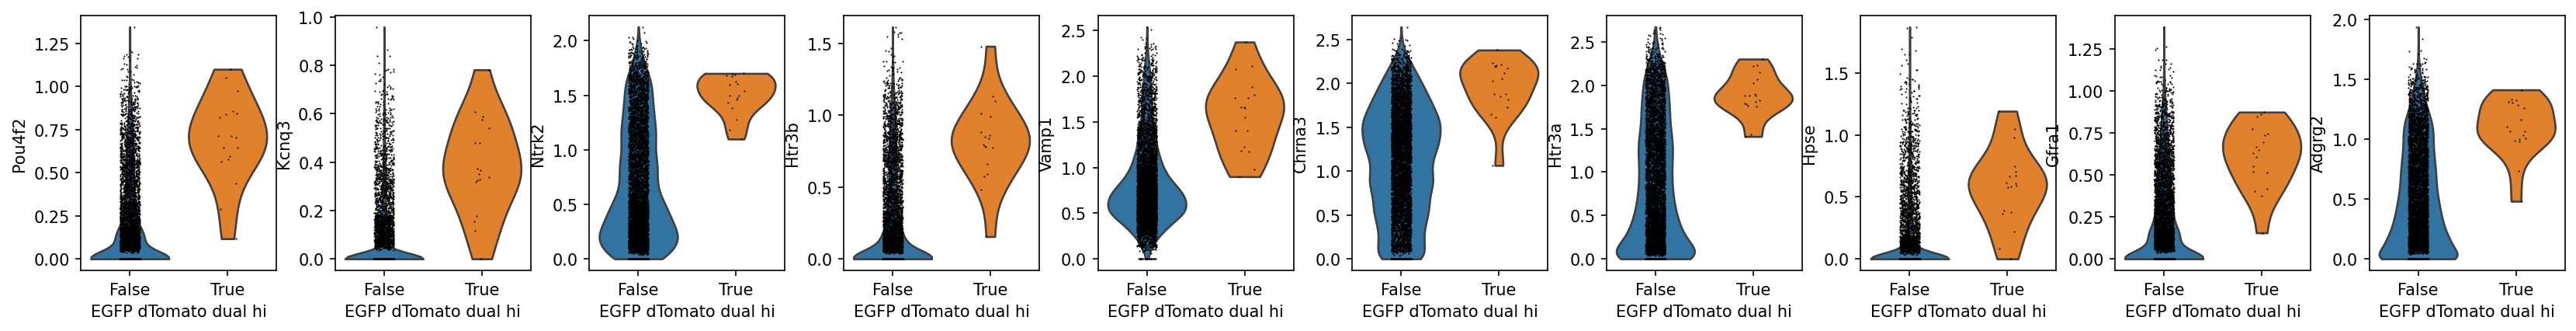

In [17]:
sc.pl.violin(adata, keys = top10, groupby = 'EGFP_dTomato_dual_hi', cmap = 'Reds')

Previous studies have reported that Chrna3⁺ neurons can be further stratified into Chrna3-high and Chrna3-low subgroups. Could we examine Chrna3 expression levels in Double⁺ neurons and compare them either to other CGRP-γ neurons or to the broader population of Chrna3⁺ neurons?

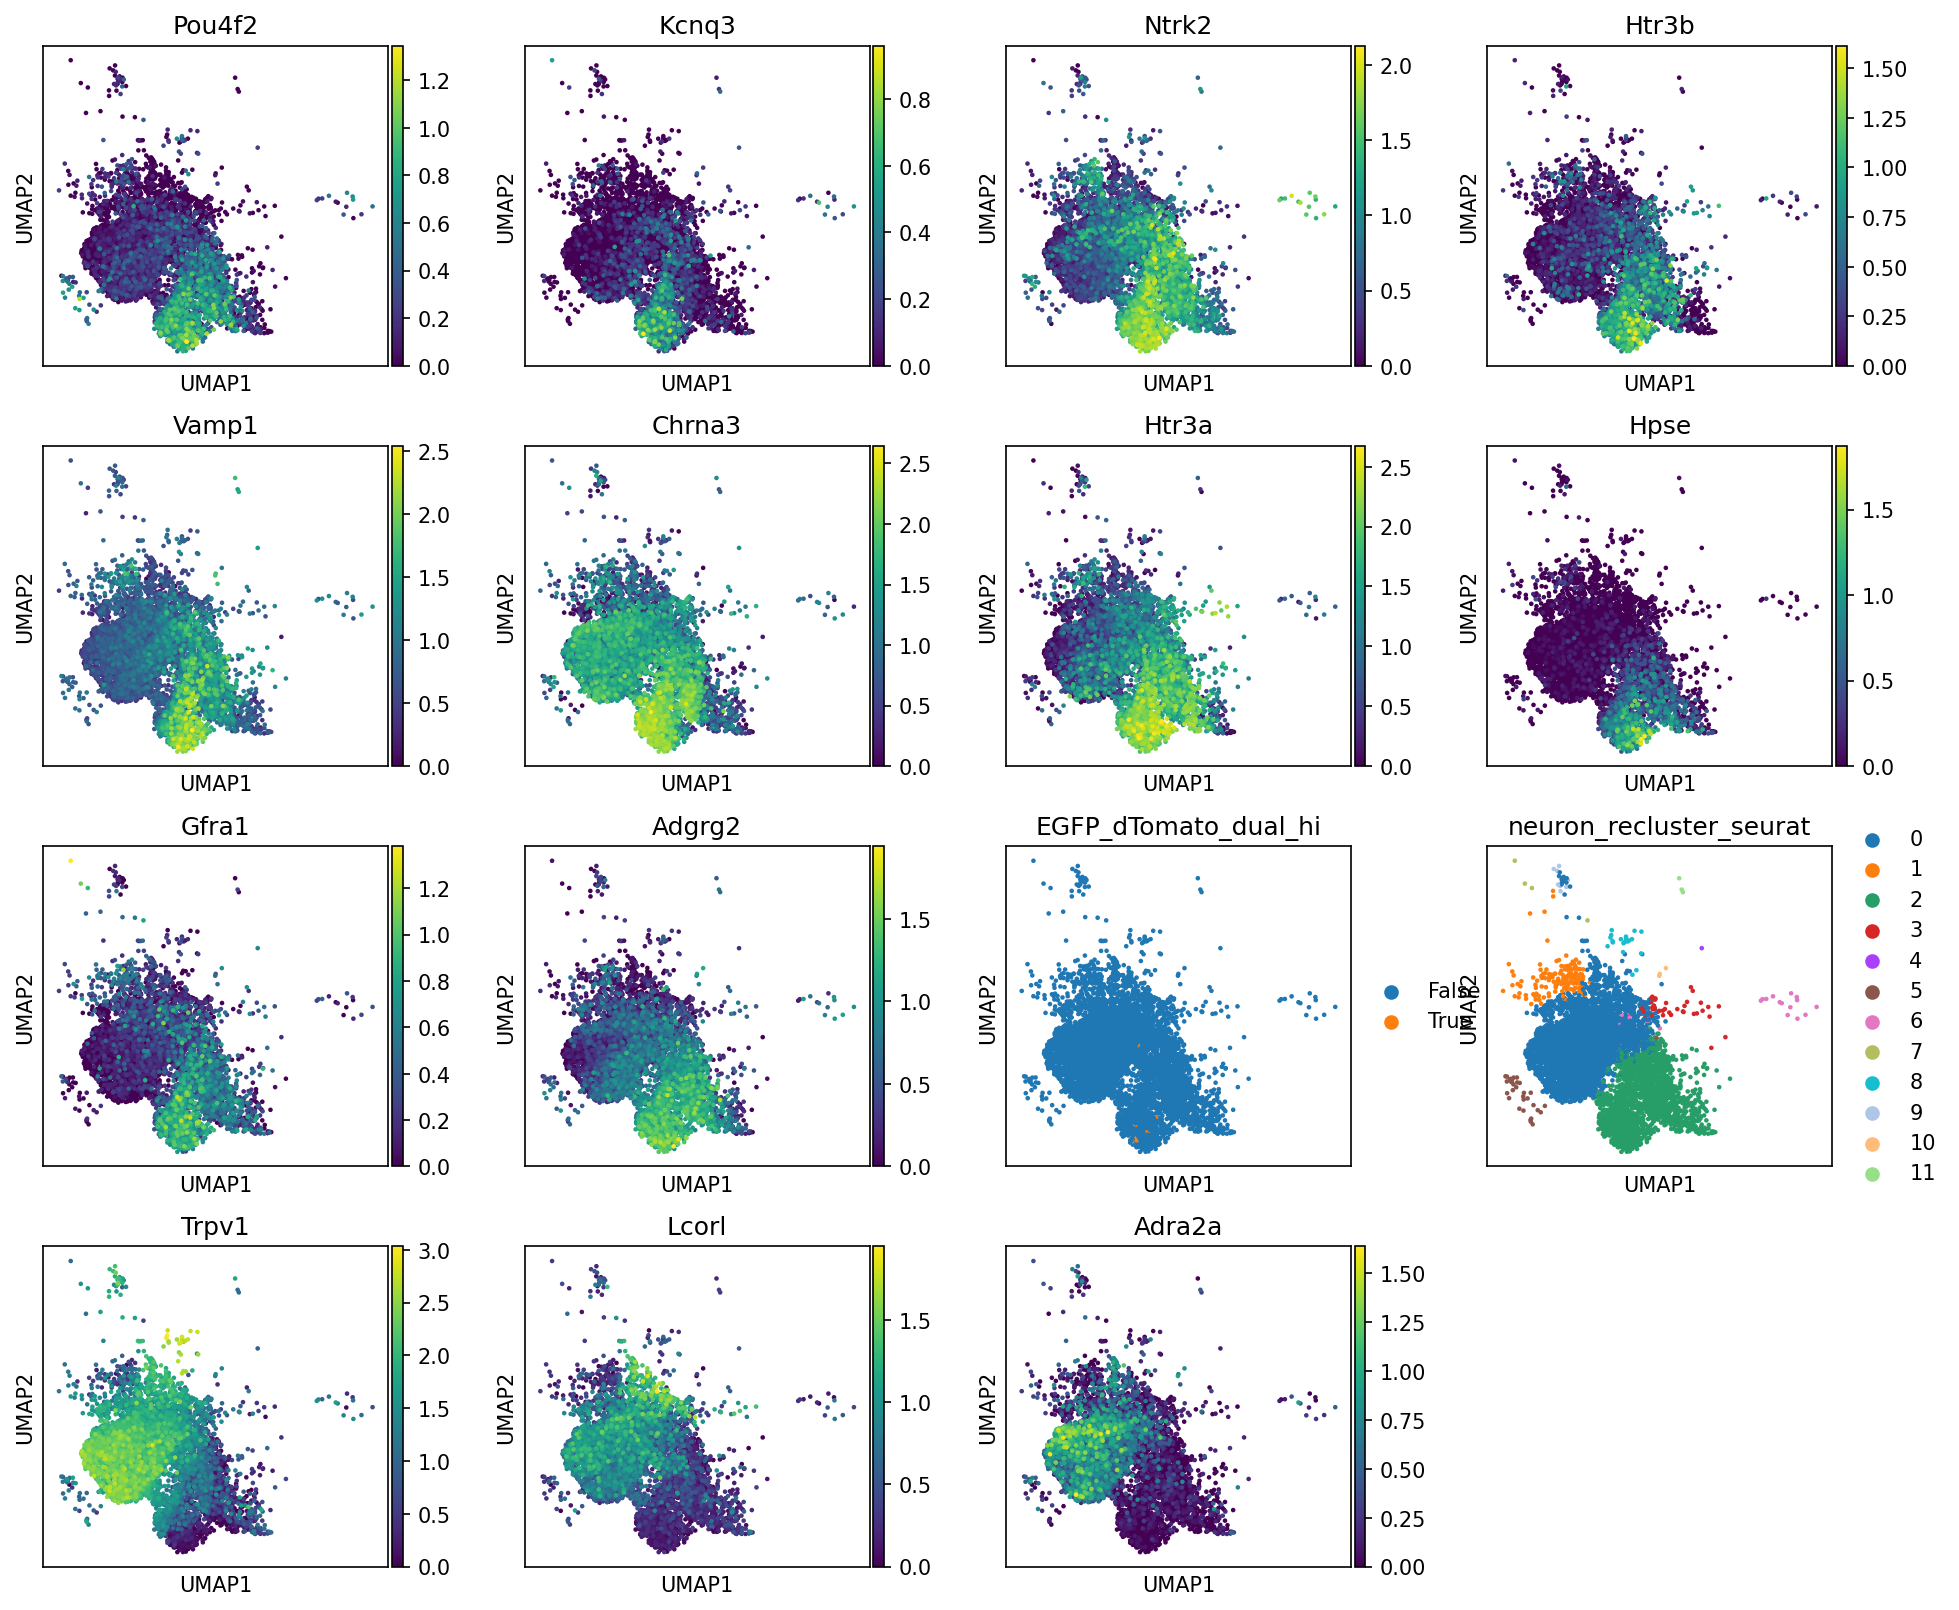

In [18]:
sc.pl.umap(adata, color = top10 +['EGFP_dTomato_dual_hi', 'neuron_recluster_seurat', 'Trpv1', 'Lcorl', 'Adra2a'])

 In addition, in Ginty’s dataset, while you have shown the double-positive signature, could CGRP-γ neurons be further subdivided into finer subtypes (e.g., γ1 vs. γ2), such as Adra2a⁺ versus Adra2a⁻ or Chrna3-high versus Chrna3-low populations?

Heatmap of mast cell mediator genes in double positive neurons vs. single bladder neurons

## Bladder-innervating neurons only

In [36]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [37]:
mast_genes = ['Mrgpra1', 'Mrgpra2b', 'Mrgpra3', 'Mrgprb4', 'Mrgprd', 'Mrgprx1']

In [41]:
adata.obs["bladder_innervating"] = "other"

adata.obs.loc[
    adata.obs["dTomato_Seq2_hi"],
    "bladder_innervating"
] = "single_positive"

adata.obs.loc[
    adata.obs["EGFP_dTomato_dual_hi"],
    "bladder_innervating"
] = "double_positive"

In [42]:
adata.obs.bladder_innervating.value_counts()

bladder_innervating
other              22303
single_positive       89
double_positive       19
Name: count, dtype: int64

In [43]:
# subset to just bladder neurons
adata = adata[adata.obs["bladder_innervating"] != "other"].copy()

adata.obs["bladder_innervating"] = (
    adata.obs["bladder_innervating"]
    .astype("category")
    .cat.remove_unused_categories()
)

In [44]:
adata.obs.bladder_innervating.value_counts()

bladder_innervating
single_positive    89
double_positive    19
Name: count, dtype: int64

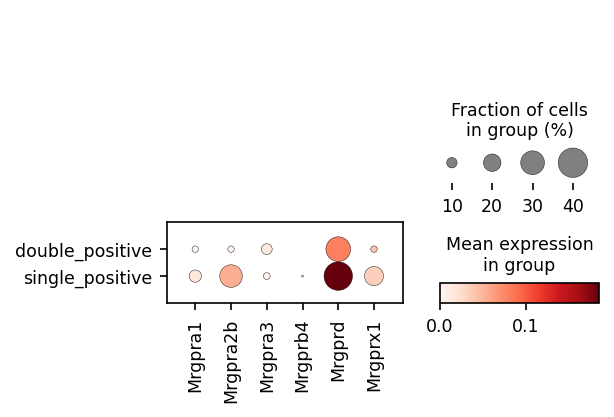

In [45]:
sc.pl.dotplot(adata, var_names = mast_genes, groupby = 'bladder_innervating')

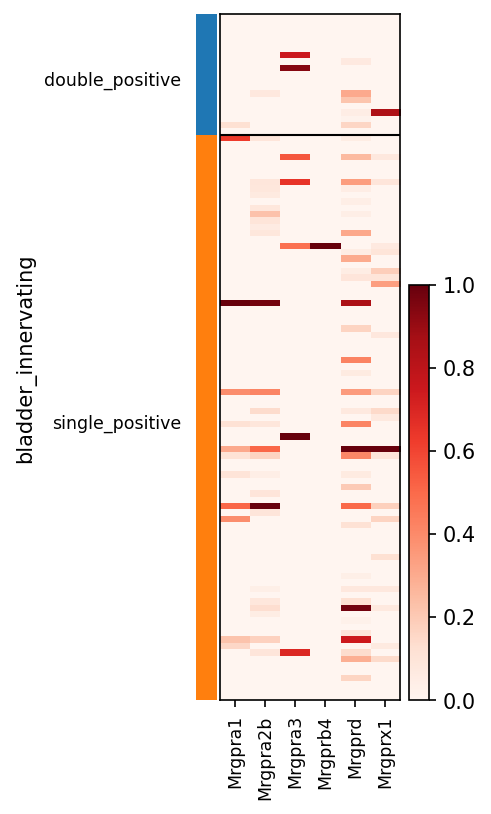

In [46]:
sc.pl.heatmap(adata, var_names = mast_genes, groupby = 'bladder_innervating', cmap = 'Reds', standard_scale = 'var')

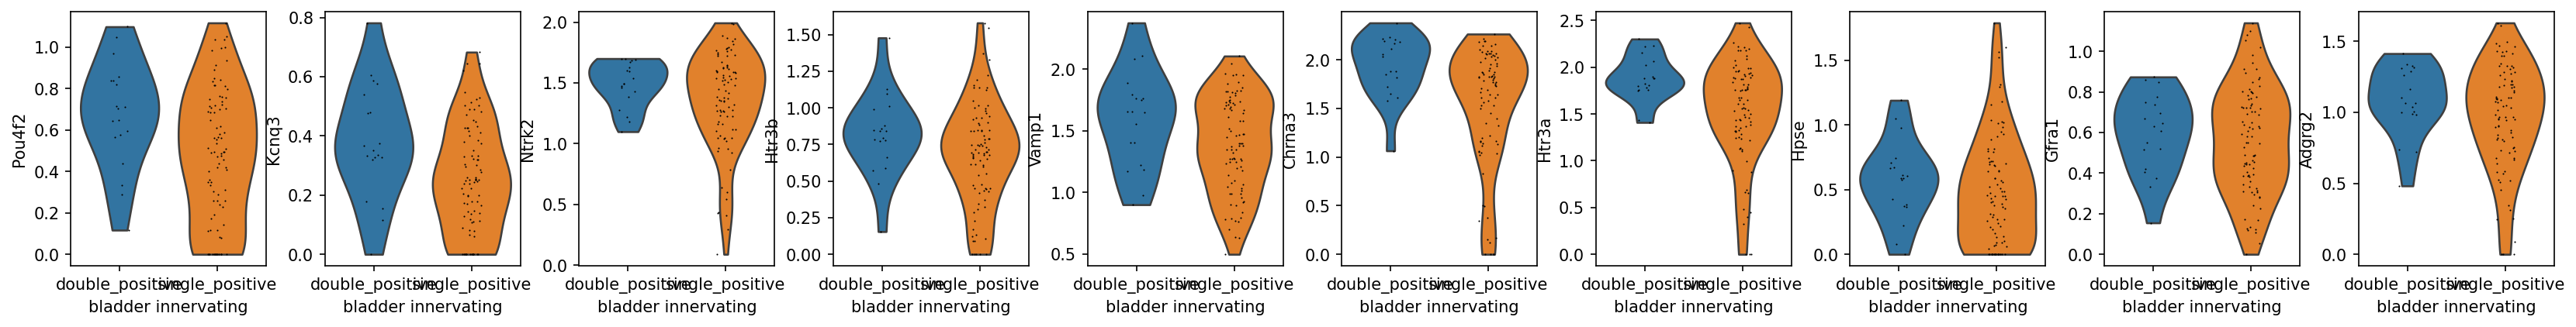

In [47]:
sc.pl.violin(adata, keys = top10, groupby = 'bladder_innervating', cmap = 'Reds')

/tmp/ipykernel_3380/1375644694.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")


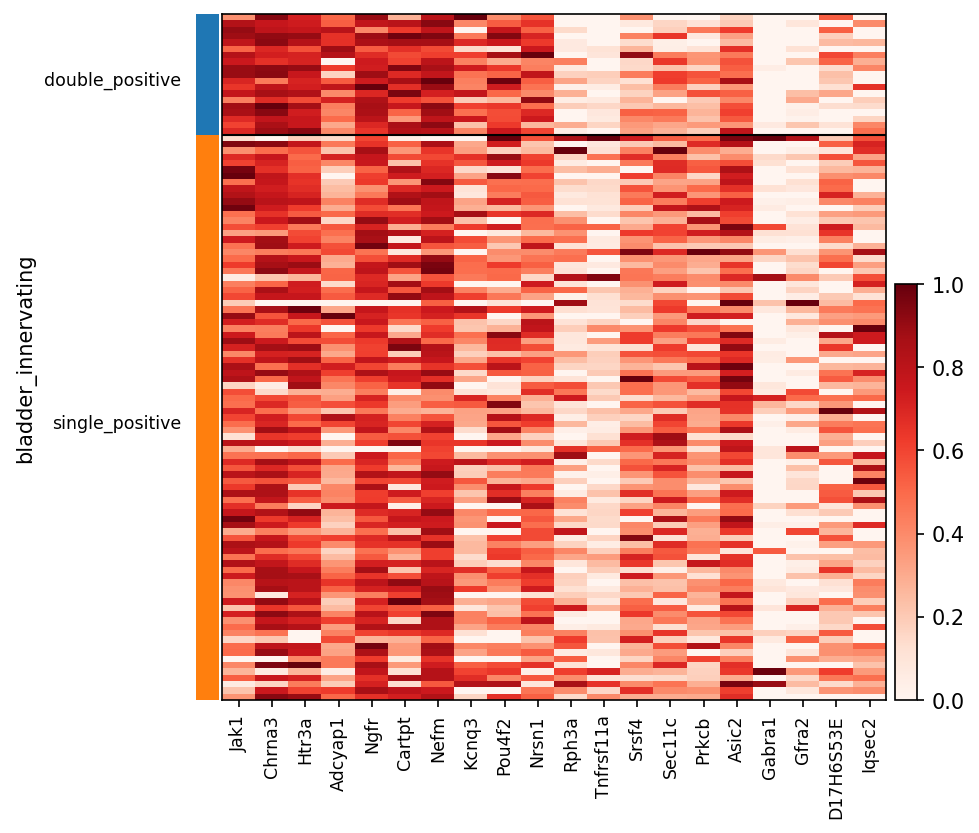

In [63]:
import scanpy as sc
import pandas as pd

# Wilcoxon DE
sc.tl.rank_genes_groups(
    adata,
    groupby="bladder_innervating",
    method="wilcoxon"
)

# Extract top 10 genes per group
markers = sc.get.rank_genes_groups_df(adata, group=None)

genes_use = (
    markers
    .sort_values(["group", "scores"], ascending=[True, False])
    .groupby("group")
    .head(10)["names"]
    .unique()
    .tolist()
)

# Matrix plot
sc.pl.heatmap(
    adata,
    var_names=genes_use,
    groupby="bladder_innervating",
    standard_scale="var",
    cmap="Reds"
)

In [64]:
sc.tl.rank_genes_groups(
    adata,
    groupby="bladder_innervating",
    method="wilcoxon"
)

# Extract top 10 genes per group
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,double_positive,Jak1,3.029811,0.446794,0.002447,0.526031
1,double_positive,Chrna3,3.021742,0.708434,0.002513,0.526031
2,double_positive,Htr3a,2.811955,0.628339,0.004924,0.526031
3,double_positive,Adcyap1,2.767577,0.611064,0.005647,0.526031
4,double_positive,Ngfr,2.698992,0.360610,0.006955,0.526031
...,...,...,...,...,...,...
945,single_positive,Ngfr,-2.698992,-0.360610,0.006955,0.526031
946,single_positive,Adcyap1,-2.767577,-0.611064,0.005647,0.526031
947,single_positive,Htr3a,-2.811955,-0.628339,0.004924,0.526031
948,single_positive,Chrna3,-3.021742,-0.708434,0.002513,0.526031
